In [43]:
#IMPORTAÇÕES

import numpy as np
import pandas as pd
#%matplotlib inline
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.arima_model import ARMA,ARMAResults,ARIMA,ARIMAResults
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf 
from pmdarima import auto_arima 
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from statsmodels.tools.eval_measures import rmse

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

# Lendo os dados
df = pd.read_excel(
    "~/IC-Gasto-Fotovoltaico-main/Controle_Faturamento_2023.xlsx",
    sheet_name="Consumo Médio - Clientes",
)

df.drop(df.iloc[:, 48:68], inplace=True, axis=1)
df.drop("Nº Cliente", inplace=True, axis=1)
df.drop("Cliente", inplace=True, axis=1)

df = df.head()

df = df.transpose()
df = df.rename(columns=df.iloc[0])
df.drop("UC", inplace=True, axis=0)
df.dropna(inplace=True)

# transformando índice em datetime
df.index
some_dates = np.array(df.index, dtype="datetime64[D]")
idx = pd.DatetimeIndex(some_dates)
df["idx"] = idx
df.set_index("idx", inplace=True)
df.index.freq = "MS"

In [44]:
df.head()

,3003858507,3001084033,3011373971,3001449459,3011504476
idx,,,,,
2019-06-01,1246.0,7160.0,440.0,960.0,1560.0
2019-07-01,1081.0,6520.0,600.0,920.0,1280.0
2019-08-01,1184.0,6840.0,680.0,1120.0,1360.0
2019-09-01,1549.0,7440.0,760.0,1040.0,1680.0
2019-10-01,2045.0,6920.0,560.0,1120.0,1680.0


In [45]:
auto_arima(
    df[3001084033],
    m=12,
    seasonal=True,
).summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   45
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -363.204
Date:                Fri, 27 Sep 2024   AIC                            732.408
Time:                        11:51:45   BIC                            737.828
Sample:                    06-01-2019   HQIC                           734.428
                         - 02-01-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   2739.4002    813.241      3.368      0.001    1145.478    4333.323
ar.L1          0.5712      0.130      4.383      0.000       0.316       0.827
sigma2      5.983e+05   1.23e+05      4.863      0.000    3.57e+05    8.39e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.26   Jarque-Bera (JB):                 1.02
Prob(Q):                              0.61   Prob(JB):                         0.60
Heteroskedasticity (H):               1.12   Skew:                            -0.34
Prob(H) (two-sided):                  0.83   Kurtosis:                         3.27
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [46]:
model = SARIMAX(df[3001084033].astype(float), order=(5, 1, 5), seasonal_order=(10, 0, 10, 12))
results = model.fit();

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           31     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  7.98618D+00    |proj g|=  8.41403D-01


 This problem is unconstrained.



At iterate    5    f=  7.91012D+00    |proj g|=  1.76357D-01

At iterate   10    f=  7.89457D+00    |proj g|=  2.04265D-02

At iterate   15    f=  7.88200D+00    |proj g|=  5.14697D-02

At iterate   20    f=  7.87529D+00    |proj g|=  1.46631D-02

At iterate   25    f=  7.86443D+00    |proj g|=  5.15338D-02

At iterate   30    f=  7.85104D+00    |proj g|=  6.08717D-02

At iterate   35    f=  7.84200D+00    |proj g|=  4.78115D-02

At iterate   40    f=  7.84062D+00    |proj g|=  1.07110D-02

At iterate   45    f=  7.83893D+00    |proj g|=  1.31828D-02

At iterate   50    f=  7.83702D+00    |proj g|=  1.09692D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tn

In [47]:
end = len(df)-1

In [48]:
predictions = results.predict(start=0, end=end, dynamic=False, typ="levels").rename(
    "Predição SARIMA"
)

In [49]:
half = df[3001084033].iloc[23:]
half_pred = predictions.iloc[23:]

mape = mean_absolute_percentage_error(half, half_pred)
print("MAPE: {:.2f}%".format(mape*100))

MAPE: 7.59%


In [50]:
mae = mean_absolute_error(half, half_pred)
print("MAE: {:.2f}".format(mae))

MAE: 488.25


In [51]:
wmape = mean_absolute_percentage_error(half, half_pred, sample_weight=half)
print("WMAPE: {:.2f}%".format(wmape*100))

WMAPE: 7.69%


In [52]:
error = rmse(half, half_pred)
print(f'RMSE Error: {error:11.10}')

RMSE Error: 600.9637919


In [68]:
normal_predictions = results.predict(start=0, end=end+48, dynamic=False, typ="levels").rename(
    "Predições SARIMA"
)

[Text(0.5, 0, 'Data'), Text(0, 0.5, 'Consumo')]

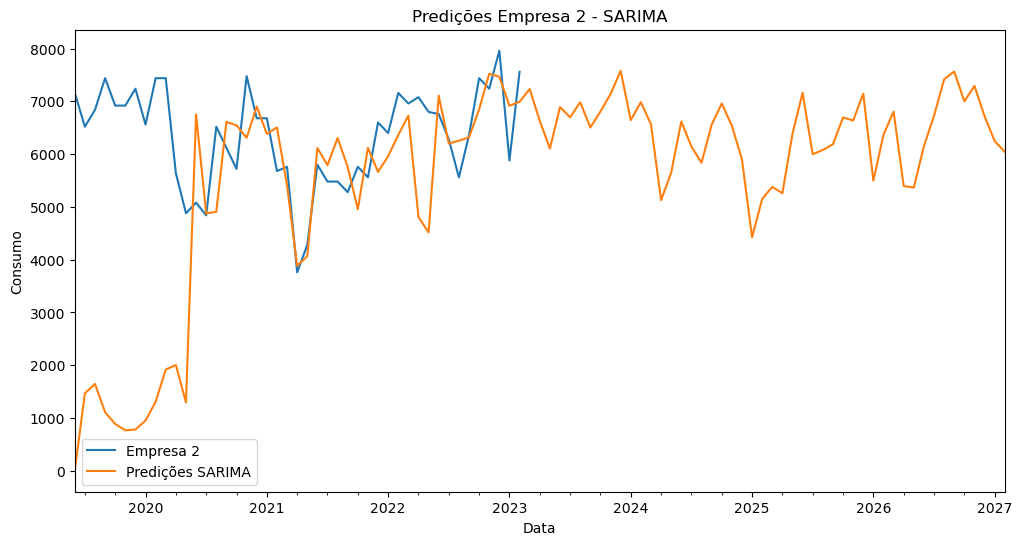

In [69]:
title = "Predições Empresa 2 - SARIMA"
ylabel = "Consumo"
xlabel = "Data"

ax = df[3001084033].plot(legend=True, figsize=(12, 6), title=title, label="Empresa 2")
normal_predictions.plot(legend=True)
ax.autoscale(axis="x", tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)

In [55]:
# Duplicando os dados
df_aug = pd.concat([df, df])

#Ajustando o índice para os dados duplicados
new_index = pd.date_range(start=df_aug.index.min(), periods=len(df_aug), freq="MS")
df_aug.index = new_index

In [56]:
model = SARIMAX(
    df_aug[3001084033].astype(float), order=(7, 0, 7), seasonal_order=(5, 1, 5, 12)
)
results = model.fit()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           25     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  7.37166D+00    |proj g|=  6.78803D-01


 This problem is unconstrained.



At iterate    5    f=  7.13326D+00    |proj g|=  2.96650D-02

At iterate   10    f=  7.11277D+00    |proj g|=  5.85130D-02

At iterate   15    f=  7.09694D+00    |proj g|=  9.32116D-02

At iterate   20    f=  7.08535D+00    |proj g|=  5.01604D-02

At iterate   25    f=  7.07424D+00    |proj g|=  2.91371D-02

At iterate   30    f=  7.07151D+00    |proj g|=  1.74363D-02

At iterate   35    f=  7.06871D+00    |proj g|=  3.00295D-02

At iterate   40    f=  7.06787D+00    |proj g|=  7.41682D-03

At iterate   45    f=  7.06759D+00    |proj g|=  4.79722D-03

At iterate   50    f=  7.06736D+00    |proj g|=  4.13290D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tn

In [61]:
augmented_predictions = results.predict(
    start=0, end=89, dynamic=False, typ="levels"
).rename("Predições SARIMA")

augmented_future_predictions = results.predict(
    start=0, end=89 + 48, dynamic=False, typ="levels"
).rename("Predições SARIMA")

In [62]:
half = df_aug[3001084033].iloc[45:]
half_pred = augmented_predictions.iloc[45:]

mape = mean_absolute_percentage_error(half, half_pred)
print("MAPE: {:.2f}%".format(mape*100))

MAPE: 9.80%


In [ ]:
error = rmse(half, half_pred)
print(f'RMSE Error: {error:11.10}')

In [ ]:
mae = mean_absolute_error(half, half_pred)
print("MAE: {:.2f}".format(mae))

In [ ]:
wmape = mean_absolute_percentage_error(half, half_pred, sample_weight=half)
print("WMAPE: {:.2f}%".format(wmape*100))

[Text(0.5, 0, 'Data'), Text(0, 0.5, 'Consumo(KWh)')]

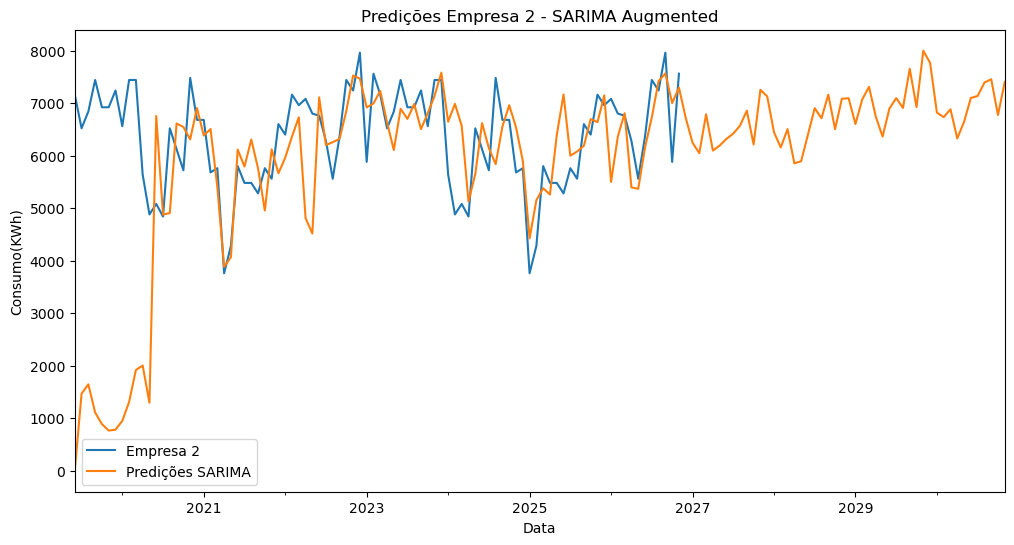

In [63]:
title = "Predições Empresa 2 - SARIMA Augmented"
ylabel = "Consumo(KWh)"
xlabel = "Data"

ax = df_aug[3001084033].plot(figsize=(12, 6), title=title,legend=True, label="Empresa 2")
augmented_future_predictions.plot(legend=True)
ax.autoscale(axis="x", tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)

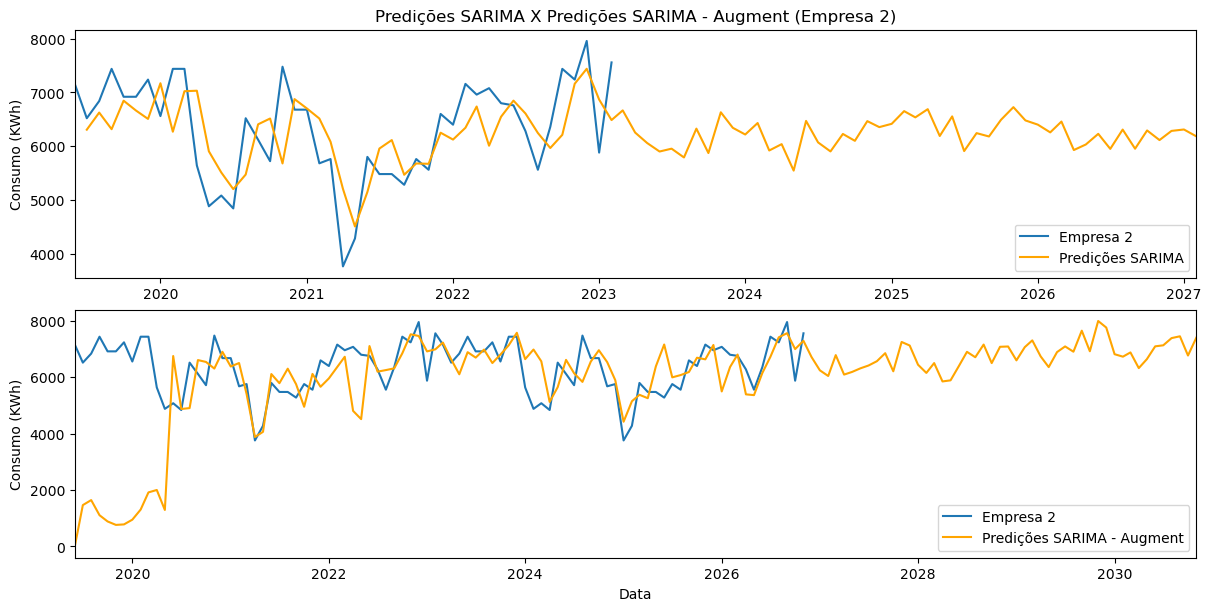

In [67]:
title = "Predições SARIMA X Predições SARIMA - Augment (Empresa 2)"
ylabel = "Consumo (KWh)"
xlabel = "Data"
fig, (ax1, ax2) = plt.subplots(2, 1, layout='constrained',figsize=(12,6))
#ax1 = df[3001449459].plot(label="MD Predial - 1")
#ax2 = df[3011504476].plot(label="MD Predial - 2")
ax1.plot(df[3001084033].index,df[3001084033],label="Empresa 2")
ax1.plot(normal_predictions.index,normal_predictions,label="Predições SARIMA",color='orange')
ax1.set(ylabel=ylabel,title=title)
ax1.legend(loc="lower right")
ax1.autoscale(axis="x", tight=True)
ax2.plot(df_aug[3001084033].index,df_aug[3001084033],label="Empresa 2")
ax2.plot(augmented_future_predictions.index,augmented_future_predictions,label="Predições SARIMA - Augment",color='orange')
ax2.set(xlabel=xlabel, ylabel=ylabel)
ax2.legend(loc="lower right")
ax2.autoscale(axis="x", tight=True)

plt.savefig("empr2_comp_graph.png")